In [104]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
from datetime import date, datetime, timedelta, timezone
from astroquery.jplhorizons import Horizons
import astropy.units as u
import pandas as pd
import xarray as xr
from tqdm import tqdm
import calendar
import time
from matplotlib.patches import Rectangle
from astropy.coordinates import AltAz, EarthLocation, SkyCoord, get_body, get_sun
from astropy.time import Time
import multiprocessing

from utils import *

%load_ext autoreload
%autoreload 2

ephempath = '/Users/isabelkain/Desktop/Twilight_/twilight-observing-tool/ephemeris-tables/'
toipath = '/Users/isabelkain/Desktop/Twilight_/twilight-observing-tool'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
def sep_arcsec_to_au(theta, d=100.):
    '''
    theta :: angular separation (arcseconds)
    d     :: distance to target (pc)
    '''
    
    sep = ((theta * u.arcsec).to_value(u.radian) * (d * u.pc)).to_value(u.au)
    
    return sep

def sep_au_to_arcsec(sep, d=100.):
    '''
    sep   :: physical separation (au)
    d     :: distance to target (pc)
    '''
    
    theta = ((sep * u.au).to(u.pc) / (d * u.pc) * u.radian).to_value(u.arcsec)
    
    return theta


sep_arcsec_to_au(0.2)

np.float64(20.000000000000004)

In [216]:
# Read in list of TOIs from ExoFOP database.
# Parameters:
# • dec > -30
# • Confirmed planet, known planet, or planet candidate
# • No magnitude cutoffs, assuming TESS stars are bright
# • Stellar companion at separation <= 1.5 arcsec


toi_list = pd.read_csv(f'{toipath}/exofop_dec-30_starsep1500mas_2026aug02.csv', 
                       skiprows=2, on_bad_lines='warn');

print('Unique TOIs:', len(toi_list['TOI'].unique()))
display(toi_list.head())


# Make version of the list without duplicate TOIs
toi_list_nodup = toi_list.drop_duplicates(subset='TOI')
display(toi_list_nodup.head())

Unique TOIs: 423


,TIC ID,TOI,RA,Dec,TFOPWG Disposition,Master Priority,SG1A Priority,SG1B Priority,SG2 Priority,SG3 Priority,...,H mag,H mag Unc.,K mag,K mag Unc.,Imaging pixel scale,Imaging Contrast magnitude,Imaging Contrast separation,Stellar Companion Separation,Stellar Companion Delta mag,Stellar Companion Observation date
0,290131778,123.01,21:18:47.9,-26:36:58.95,CP,3,5,5,5,4,...,7.048,0.021,6.959,0.024,0.009942,6.851,0.5,1.2810,1.7033,2018-09-18
1,290131778,123.01,21:18:47.9,-26:36:58.95,CP,3,5,5,5,4,...,7.048,0.021,6.959,0.024,0.009942,6.851,0.5,1.2800,1.6358,2018-09-18
2,290131778,123.01,21:18:47.9,-26:36:58.95,CP,3,5,5,5,4,...,7.048,0.021,6.959,0.024,0.009942,6.851,0.5,1.2760,1.7204,2018-09-18
3,290131778,123.01,21:18:47.9,-26:36:58.95,CP,3,5,5,5,4,...,7.048,0.021,6.959,0.024,0.009942,6.851,0.5,1.2894,1.8000,2018-09-25
4,290131778,123.01,21:18:47.9,-26:36:58.95,CP,3,5,5,5,4,...,7.048,0.021,6.959,0.024,0.009942,6.851,0.5,1.2920,1.8000,2018-09-25


,TIC ID,TOI,RA,Dec,TFOPWG Disposition,Master Priority,SG1A Priority,SG1B Priority,SG2 Priority,SG3 Priority,...,H mag,H mag Unc.,K mag,K mag Unc.,Imaging pixel scale,Imaging Contrast magnitude,Imaging Contrast separation,Stellar Companion Separation,Stellar Companion Delta mag,Stellar Companion Observation date
0,290131778,123.01,21:18:47.9,-26:36:58.95,CP,3,5,5,5,4,...,7.048,0.021,6.959,0.024,0.009942,6.851,0.5,1.2810,1.7033,2018-09-18
154,29857954,172.01,21:06:31.65,-26:41:34.31,CP,4,5,5,5,4,...,9.825,0.025,9.722,0.021,0.015750,6.700,1.0,1.1021,4.9000,2018-10-22
238,211438925,194.01,00:20:38.53,-23:56:08.84,KP,3,5,5,3,5,...,9.417,0.021,9.390,0.024,0.015750,5.100,1.0,0.2653,1.0000,2020-10-31
241,268766053,272.01,02:07:38.2,-20:39:42.63,KP,5,5,5,5,5,...,10.474,0.022,10.390,0.023,0.025000,5.408,0.5,0.0320,2.1400,2020-12-27
253,2758565,287.01,23:45:07.93,-17:26:57.35,PC,3,4,4,3,4,...,11.331,0.026,11.249,0.023,0.015750,5.800,1.0,0.1400,3.7100,2019-07-17


In [217]:
# toi_list_nodup[toi_list_nodup['Stellar Companion Delta mag'] < 0]
toi_list_nodup.columns

Index(['TIC ID', 'TOI', 'RA', 'Dec', 'TFOPWG Disposition', 'Master Priority',
       'SG1A Priority', 'SG1B Priority', 'SG2 Priority', 'SG3 Priority',
       'SG4 Priority', 'SG5 Priority', 'Teff (TOI)', 'log(g) (TOI)',
       'Stellar Radius (TOI)', 'Orbital Period (TOI)',
       'Orbital Period (TOI) Unc.', 'Transit Depth (TOI)',
       'Transit Depth (TOI) Unc.', 'Planet Radius (TOI)',
       'Planet Radius (TOI) Unc.', 'Equilibrium Temp (TOI)', 'J mag',
       'J mag Unc.', 'H mag', 'H mag Unc.', 'K mag', 'K mag Unc.',
       'Imaging pixel scale', 'Imaging Contrast magnitude',
       'Imaging Contrast separation', 'Stellar Companion Separation',
       'Stellar Companion Delta mag', 'Stellar Companion Observation date'],
      dtype='str')

In [ ]:
# # Make len(5) toi_list for testing

# toi_list_short = toi_list_nodup[:5]
# toi_list_short.to_csv(f'{toipath}/toi_list_short.csv')
# toi_list_short

Text(0, 0.5, 'Unique TOI count')

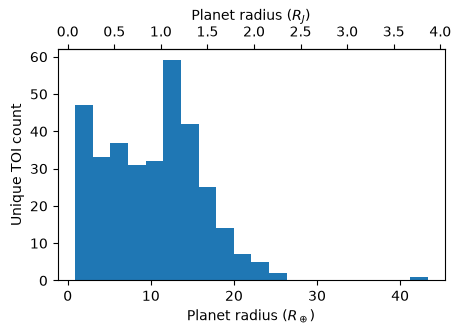

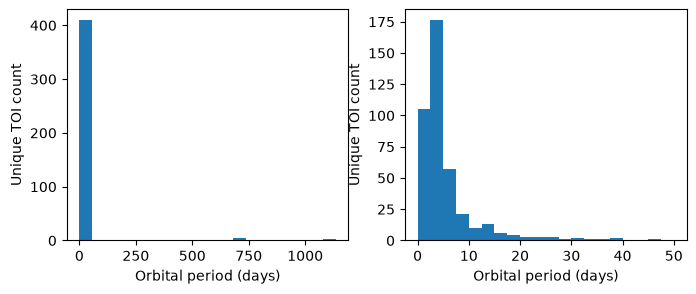

In [220]:
# Plot planet properties in this TOI sample

# def Mearth2Mjup(Me):
#     Mj = (Me * u.M_earth).to_value(u.M_jup)
#     return Mj

# def Mjup2Mearth(Mj):
#     Me = (Mj * u.M_jup).to_value(u.M_earth)
#     return Me

def Rearth2Rjup(Re):
    Rj = (Re * u.R_earth).to_value(u.R_jup)
    return Rj

def Rjup2Rearth(Rj):
    Re = (Rj * u.R_jup).to_value(u.R_earth)
    return Re

# Radius

fig, ax = plt.subplots(1,1, figsize=(5,3))
ax.hist( toi_list_nodup['Planet Radius (TOI)'].values, bins=20 )
ax.set_xlabel('Planet radius ($R_\oplus$)')
ax.set_ylabel('Unique TOI count')

secax = ax.secondary_xaxis('top', functions=(Rearth2Rjup, Rjup2Rearth))
secax.set_xlabel('Planet radius ($R_J$)')


# Period

# plt.figure()
# plt.
# plt.xlabel('Orbital period (days)')
# plt.ylabel('Unique TOI count')


fig, ax = plt.subplots(1,2, figsize=(8,3))
ax[0].hist( toi_list_nodup['Orbital Period (TOI)'].values, bins=20 )
ax[0].set_xlabel('Orbital period (days)')
ax[0].set_ylabel('Unique TOI count')
ax[1].hist( toi_list_nodup['Orbital Period (TOI)'].values, bins=20, range=(0,50) )
ax[1].set_xlabel('Orbital period (days)')
ax[1].set_ylabel('Unique TOI count')


# plt.figure()
# plt.hist( toi_list_nodup['Master Priority'].values, bins=5, alpha=0.5 )
# plt.hist( toi_list_nodup['SG2 Priority'].values, bins=5, alpha=0.5 )
# plt.hist( toi_list_nodup['SG3 Priority'].values, bins=5, alpha=0.5 )
# plt.xlabel('SG Priority')
# plt.ylabel('Unique TOI count')

Text(0, 0.5, 'Unique TOI count')

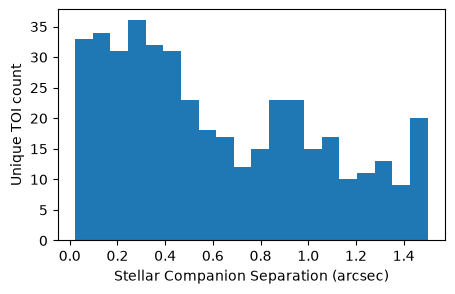

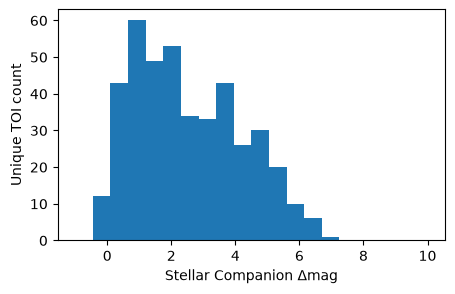

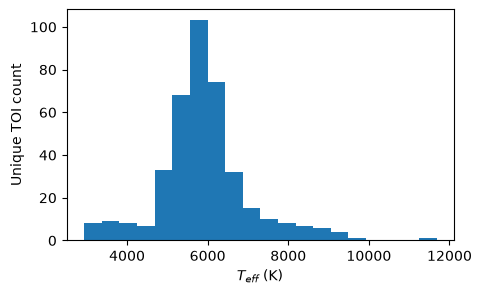

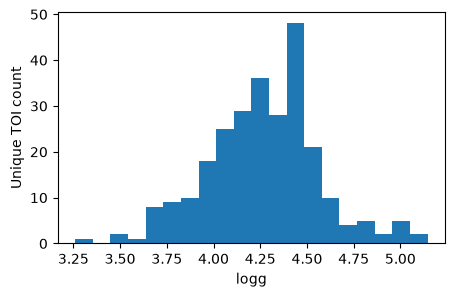

In [219]:
# Plot stellar properties in this TOI sample

plt.figure(figsize=(5,3))
plt.hist( toi_list_nodup['Stellar Companion Separation'].values, bins=20 )
plt.xlabel('Stellar Companion Separation (arcsec)')
plt.ylabel('Unique TOI count')


plt.figure(figsize=(5,3))
plt.hist( toi_list_nodup['Stellar Companion Delta mag'].values, bins=20, range=(-1, 10) ) # -100 doesnt look like a real value
plt.xlabel('Stellar Companion $\Delta$mag')
plt.ylabel('Unique TOI count')

plt.figure(figsize=(5,3))
plt.hist( toi_list_nodup['Teff (TOI)'].values, bins=20)
plt.xlabel('$T_{eff}$ (K)')
plt.ylabel('Unique TOI count')

plt.figure(figsize=(5,3))
plt.hist( toi_list_nodup['log(g) (TOI)'].values, bins=20)
plt.xlabel('logg')
plt.ylabel('Unique TOI count')

In [150]:
# Test TOI azel/sunrise times code; report time performance

start_time = time.time()

# Read in solar ephemeris for today's date
sunset_UTC, sunset_az, _, _, _, _, sunrise_UTC, sunrise_az, _, _, _, _,  = read_solar_ephemeris('10-1-2026')

# Set observatory location
keck = EarthLocation.of_site('Keck')

# Read in (ra, dec) of one TOI host
# toi_coord = SkyCoord.from_name("TOI 309.01") # is up August 2026
toi_coord = SkyCoord.from_name("TOI 489.01") # set to 8-30-2026, is up thru second half of twilight
# toi_coord = SkyCoord.from_name("TOI 2781.01") # set to 8-30-2026, is up thru second half of twilight
# toi_coord = SkyCoord(toi_list['RA'][0], toi_list['Dec'][0], unit=(u.hourangle, u.deg))

# Convert from (ra, dec) to (az, el) at SUNRISE from Keck II
toi_coord_azel = toi_coord.transform_to(AltAz(obstime=Time(datetime.strptime(sunrise_UTC, '%Y-%b-%d %H:%M')), location=keck))
toi_az = toi_coord_azel.az.value
toi_el = toi_coord_azel.alt.value
print(toi_az, toi_el)

# Convert from (ra, dec) to (az, el) at SUNSET from Keck II
toi_coord_azel = toi_coord.transform_to(AltAz(obstime=Time(datetime.strptime(sunset_UTC, '%Y-%b-%d %H:%M')), location=keck))
toi_az = toi_coord_azel.az.value
toi_el = toi_coord_azel.alt.value
print(toi_az, toi_el)

end_time = time.time()
execution_time = end_time - start_time
print(f'Execution time: {execution_time:0.3f} s.') # typical time for first execution: 2.5s +- 0.5s.
    

User-entered observation date: 2026-10-01 00:00:00
Sunset time: 2026-Oct-01 04:20
Sunrise time: 2026-Oct-01 16:03
115.38217411916418 58.89117200178562
313.39506869883337 -55.85054103447005
Execution time: 0.009 s.


In [172]:
# Go run check_TOI_visibility.py -- should take <5 minutes.
# Results are saved as vis_matrix_{fname}.npy
# This array is a (N_TOI x 365) boolean array; if a cell is True, that means that TOI is visible
# and within Keck's pointing constraints and our user-set twilight pointing constraints for that morning twi.

# vis_matrix = np.load(f'{toipath}/vis_matrix_2026aug02.npy')
# np.shape(vis_matrix)

vis_matrix = np.load(f'{toipath}/vis_matrix_2026aug02.npy')
np.shape(vis_matrix)

(423, 365)

Text(0, 0.5, '# nights observable during morning twilight')

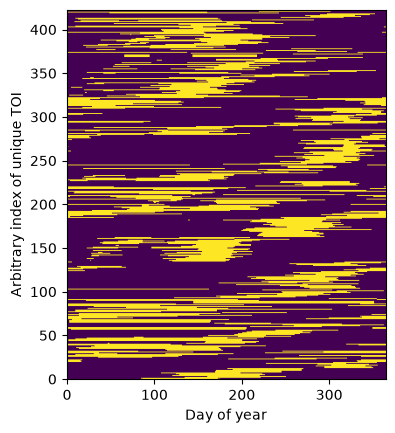

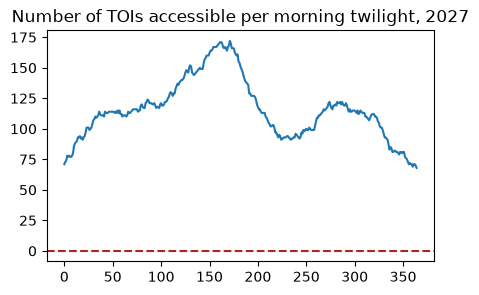

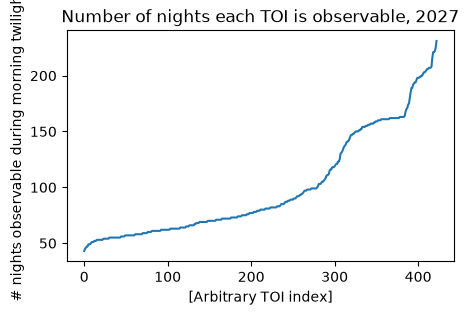

In [186]:
plt.imshow(vis_matrix, origin='lower')
plt.xlabel('Day of year')
plt.ylabel('Arbitrary index of unique TOI')

num_TOIs_visible = np.sum(vis_matrix, axis=0)
num_nights_visible = np.sum(vis_matrix, axis=1)

plt.figure(figsize=(5,3))
plt.plot( num_TOIs_visible )
plt.axhline(0, ls='--', color='firebrick')
plt.title('Number of TOIs accessible per morning twilight, 2027\n(i.e. )')

plt.figure(figsize=(5,3))
plt.plot( np.sort(num_nights_visible) )
plt.title('Number of nights each TOI is observable, 2027')
plt.xlabel('[Arbitrary TOI index]')
plt.ylabel('# nights observable during morning twilight')